# **Concentration and Diversity in Collaboration Networks in Electrical Engineering: Evidence from Brazilian Researchers**

---

### **Authors**

- **Fernando A. do Carmo**  
  ORCID: https://orcid.org/0000-0003-4594-5924  

- **Gustavo S. Silva**  
  ORCID: https://orcid.org/0009-0001-1559-3465  

- **Raimundo C. S. Freire**  
  ORCID: https://orcid.org/0000-0002-5395-7143  

- **Antonio F. L. Jacob Jr**  
  ORCID: https://orcid.org/0000-0002-9415-7265  

- **Fábio M. F. Lobato**  
  ORCID: https://orcid.org/0000-0002-6282-0368  

---

<br>

#### **Notes on Supplementary Material**

This notebook contains the computational procedures, data analysis, and reproducibility materials associated with the article. All figures and tables generated here correspond to results discussed in the main manuscript.



# Data

In [1]:
import pandas as pd
import numpy as np

In [222]:
df_coauthorship = pd.read_csv("full_dataset.csv")
df_coauthorship.columns

Index(['autor_completo', 'co-autor_completo', 'group', 'group_coautor'], dtype='object')

In [223]:
df_coauthorship = df_coauthorship[
    # remove self-loops (author == co-author)
    df_coauthorship['autor_completo'] != df_coauthorship['co-autor_completo']
]

nodes = set(df_coauthorship["autor_completo"]).union(
    set(df_coauthorship["co-autor_completo"])
)

df_edges = df_coauthorship[["autor_completo", "co-autor_completo", "group"]].copy()
df_edges.columns = ["source", "target", "grant_level"]

node_grant_level_counts = {}

for _, row in df_edges.iterrows():
    for node in [row["source"], row["target"]]:
        if node not in node_grant_level_counts:
            node_grant_level_counts[node] = {}

        level = row["grant_level"]
        node_grant_level_counts[node][level] = (
            node_grant_level_counts[node].get(level, 0) + 1
        )

node_grant_level = {
    node: max(levels, key=levels.get)
    for node, levels in node_grant_level_counts.items()
}

df_nodes = pd.DataFrame({"name": list(nodes)})

df_nodes["grant_level"] = (
    df_nodes["name"].map(node_grant_level).fillna("Unknown")
)

unique_names = df_nodes["name"].unique()
name_to_id = {name: idx for idx, name in enumerate(unique_names)}

df_nodes_anon = df_nodes.copy()
df_nodes_anon["author_id"] = df_nodes_anon["name"].map(name_to_id)
df_nodes_anon = df_nodes_anon[["author_id", "grant_level"]]

df_edges_anon = df_edges.copy()
df_edges_anon["source"] = df_edges_anon["source"].map(name_to_id)
df_edges_anon["target"] = df_edges_anon["target"].map(name_to_id)
df_edges_anon = df_edges_anon[["source", "target", "grant_level"]]

df_nodes_anon.to_csv("nodes_dataset_anon.csv")
df_edges_anon.to_csv("edges_dataset_anon.csv")

In [3]:
df_nodes = pd.read_csv("nodes_dataset_anon.csv")
df_edges = pd.read_csv("edges_dataset_anon.csv")

In [19]:
df_nodes.head()

,Author_ID,Group
0,0,2
1,1,1D
2,2,2
3,3,1D
4,4,2


In [20]:
df_edges.head()

,Source,Target,Group
0,87,123,2
1,275,220,1C
2,275,220,1C
3,275,220,1C
4,322,311,1A


# Collaboration and Community dynamics

In [7]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from tqdm.notebook import tqdm

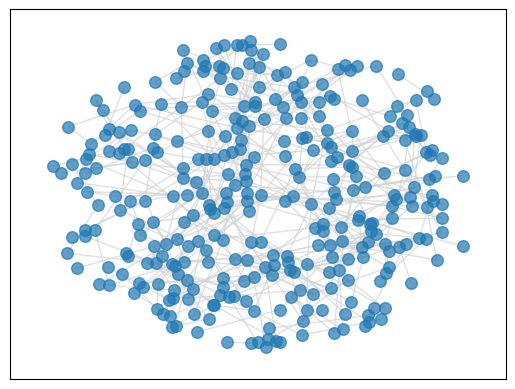

In [24]:
G = nx.Graph()
G.add_edges_from(zip(df_edges["Source"], df_edges["Target"]))
group_map = df_nodes.set_index("Author_ID")["Group"].to_dict()
nx.set_node_attributes(G, group_map, "Group")

pos = nx.spring_layout(G, seed=2025, k=0.3)

nx.draw_networkx(
    G, pos,
    node_size=70,
    with_labels=False,
    edge_color="lightgray",
    alpha=0.7
)

plt.show()

In [10]:
from rich import print as rprint

def print_info(
        info: str,
        author_id: int,
        df_nodes: pd.DataFrame = df_nodes,
        col: str = "Author_ID"
    ) -> None:
    group = df_nodes.query(f"{col} == @author_id")["Group"].item()
    rprint(f" - id={author_id} ({group}), {info}")


def print_top_k(metric_dict: dict, k: int) -> None:
    top_k = sorted(
        metric_dict.items(),
        key=lambda item: item[1],
        reverse=True
    )[:k]

    for author_id, value in top_k:
        print_info(f"{value=}", author_id)

    return None

### **Who are the most frequent primary authors?**

In [25]:
degree_centrality = nx.degree_centrality(G)
print_top_k(degree_centrality, 10)

- id=264 (2), value=0.03105590062111801

- id=171 (1D), value=0.03105590062111801

- id=135 (1D), value=0.02795031055900621

- id=4 (2), value=0.02795031055900621

- id=136 (2), value=0.024844720496894408

- id=258 (2), value=0.024844720496894408

- id=307 (2), value=0.024844720496894408

- id=52 (1C), value=0.021739130434782608

- id=44 (2), value=0.021739130434782608

- id=64 (2), value=0.021739130434782608

In [26]:
betweenness = nx.betweenness_centrality(G, normalized=True, weight="weight", seed=2025)
print_top_k(betweenness, 10)

- id=171 (1D), value=0.14680368974073454

- id=264 (2), value=0.14521094181365846

- id=45 (1D), value=0.132369672043329

- id=52 (1C), value=0.1054758151641379

- id=169 (1B), value=0.09839327464246798

- id=275 (1A), value=0.08204030108163152

- id=141 (1D), value=0.0804839725545594

- id=151 (2), value=0.0667391772459399

- id=136 (2), value=0.06662501504609819

- id=54 (2), value=0.06441090233145454

In [27]:
degree_weighted = dict(G.degree(weight="weight"))

### **Communities**

In [28]:
!pip install -qU python-louvain

In [29]:
from community import community_louvain
from collections import defaultdict
import matplotlib.cm as cm

In [30]:
partition_louvain = community_louvain.best_partition(G, weight="weight", random_state=2025)
partition_rcat = nx.get_node_attributes(G, "Group")

for partition in [partition_louvain, partition_rcat]:
    num_communities = len(set(partition.values()))
    print(f"{num_communities=}")

num_communities=32
num_communities=5


In [31]:
partitions = {
    "Louvain": partition_louvain,
    "Lattes Research Group": partition_rcat,
}

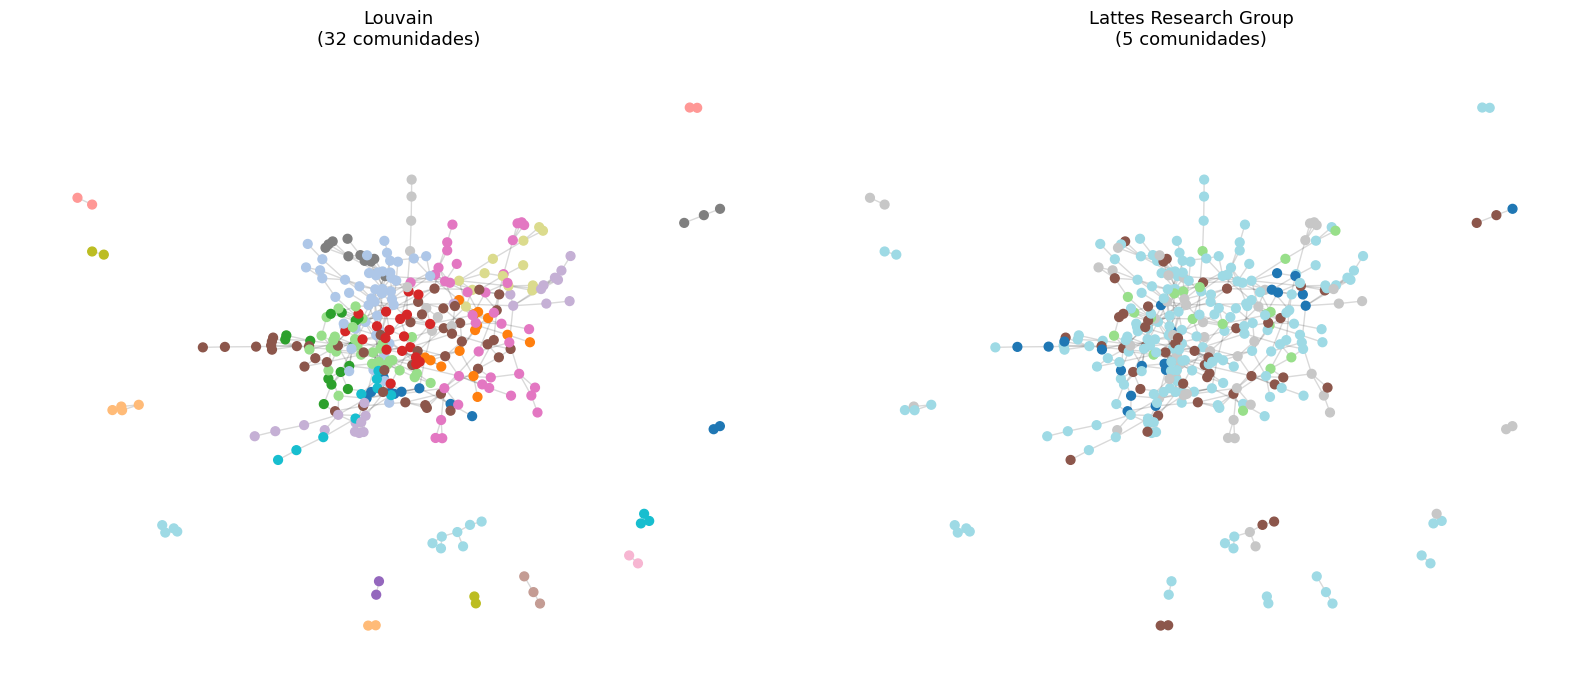

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

pos = nx.spring_layout(G, seed=2025, weight="weight")

for ax, (title, partition) in zip(axes, partitions.items()):
    communities = set(partition.values())
    num_communities = len(communities)

    cmap = plt.get_cmap("tab20", num_communities)
    comm_to_idx = {c: i for i, c in enumerate(sorted(communities))}
    node_colors = [cmap(comm_to_idx[partition[n]]) for n in G.nodes()]

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.15)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=40)
    ax.set_title(f"{title}\n({num_communities} comunidades)", fontsize=13)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [35]:
def community_layout(G, partition, seed=2025):
    """Two-level layout: position communities first, then nodes within them."""
    # contracted graph: each community becomes a node
    comm_nodes = defaultdict(list)
    for node, comm in partition.items():
        comm_nodes[comm].append(node)

    # macro layout: position of each community
    H = nx.Graph()
    H.add_nodes_from(comm_nodes.keys())
    for u, v in G.edges():
        cu, cv = partition[u], partition[v]
        if cu != cv:
            if H.has_edge(cu, cv):
                H[cu][cv]["weight"] += 1

            else:
                H.add_edge(cu, cv, weight=1)

    pos_comm = nx.spring_layout(H, seed=seed, k=2)

    # micro layout: nodes within each community
    pos = {}
    rng = np.random.default_rng(seed)
    for comm, nodes in comm_nodes.items():
        sub = G.subgraph(nodes)
        if len(nodes) == 1:
            pos[nodes[0]] = pos_comm[comm]

        else:
            pos_sub = nx.spring_layout(sub, seed=seed, center=pos_comm[comm], scale=0.15)
            pos.update(pos_sub)

    return pos

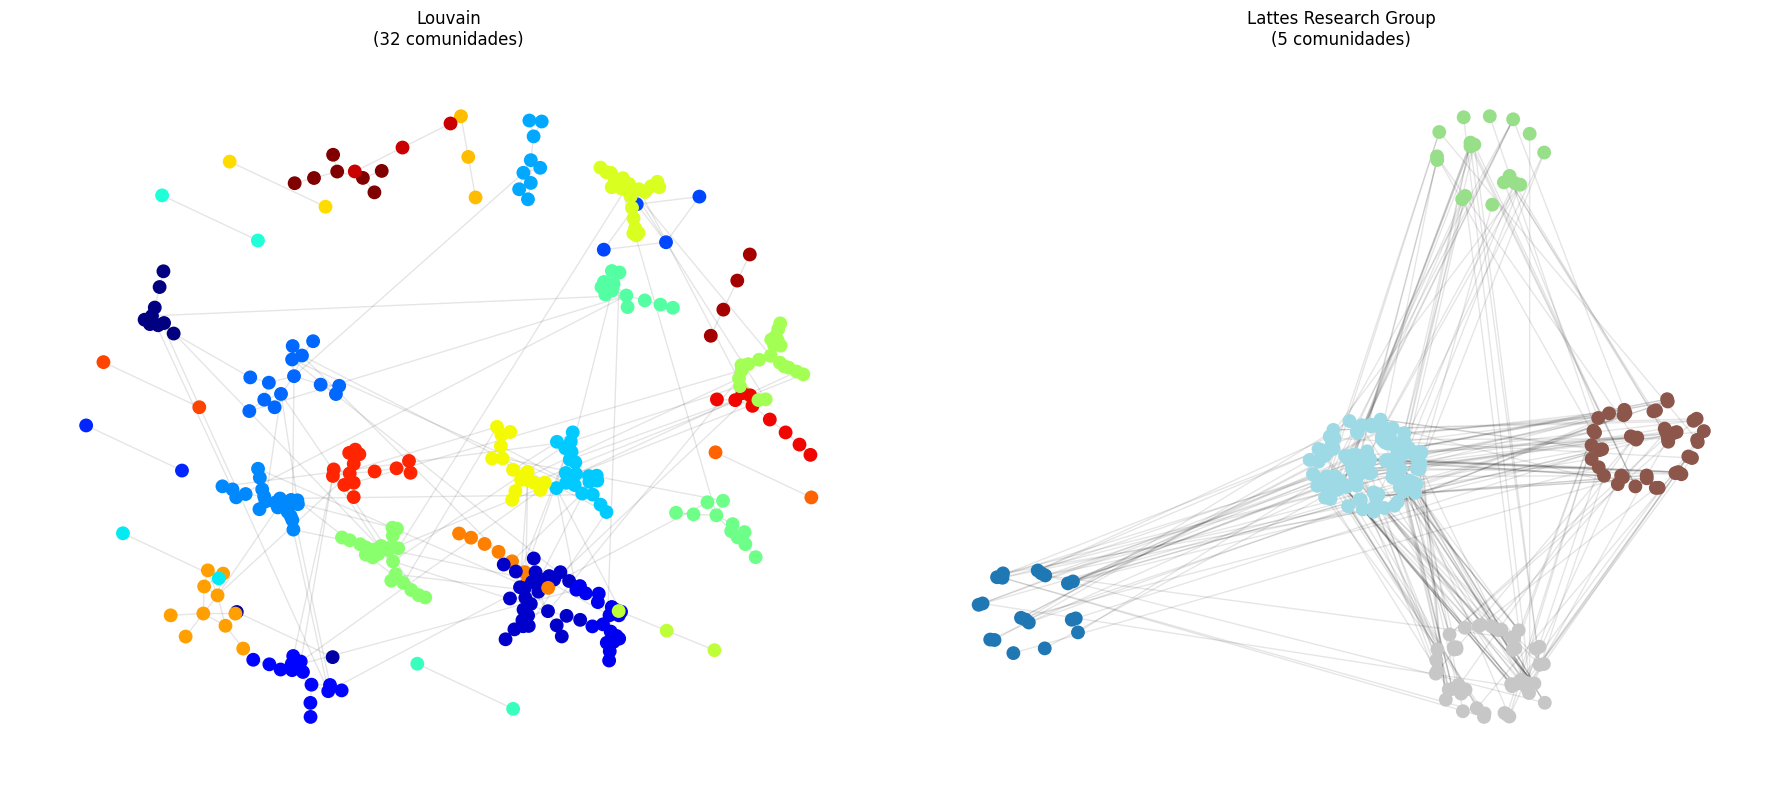

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, (title, partition) in zip(axes, partitions.items()):
    communities = sorted(set(partition.values()))
    num_c = len(communities)
    cmap = plt.get_cmap("tab20" if num_c <= 20 else "jet", num_c)
    comm_to_idx = {c: i for i, c in enumerate(communities)}

    pos = community_layout(G, partition)
    node_colors = [cmap(comm_to_idx[partition[n]]) for n in G.nodes()]

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.1)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=80)
    ax.set_title(f"{title}\n({num_c} comunidades)")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [37]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

nodes = list(G.nodes())
labels_louvain = [partition_louvain[n] for n in nodes]
labels_rcat = [partition_rcat[n] for n in nodes]

# nmi and ari close to zero = no shared structures
print(f"NMI: {normalized_mutual_info_score(labels_rcat, labels_louvain):.3f}")
print(f"ARI: {adjusted_rand_score(labels_rcat, labels_louvain):.3f}")

NMI: 0.138
ARI: 0.004


### **What is the 'influence' or 'prestige' of authors in the network, considering collaboration patterns?**

In [38]:
df_nodes_intra = pd.read_csv("nodes_intra_anon.csv")
df_edges_intra = pd.read_csv("edges_intra_anon.csv")

In [39]:
G_pagerank = nx.Graph()
G_pagerank.add_edges_from(zip(df_edges_intra["Source"], df_edges_intra["Target"]))
group_map = df_nodes_intra.set_index("Author_ID")["Group"].to_dict()
nx.set_node_attributes(G_pagerank, group_map, "Group")

In [42]:
pagerank_scores = nx.pagerank(G_pagerank, weight="weight")
print_top_k(pagerank_scores, 10)

- id=138 (2), value=0.012271124408816446

- id=63 (1B), value=0.011024128120251303

- id=155 (2), value=0.011024128120251303

- id=148 (2), value=0.010851714188231465

- id=258 (2), value=0.010801901651337174

- id=52 (1C), value=0.010273095700190884

- id=247 (1D), value=0.010273095700190884

- id=309 (1C), value=0.010273095700190884

- id=54 (2), value=0.009727372221042483

- id=45 (1D), value=0.009727372221042483

In [46]:
df_pagerank = (
    pd.DataFrame(pagerank_scores.items(), columns=["author_id", "pagerank"])
    .merge(
        df_nodes_intra,
        how="right",
        right_on="Author_ID",
        left_on="author_id"
    )
    .drop("Author_ID", axis=1)
)

df_pagerank.head()

,author_id,pagerank,Group
0,130,0.007055,1C
1,138,0.012271,2
2,277,0.005747,2
3,73,0.005747,1A
4,241,0.004033,2


In [47]:
(
    df_pagerank
    .set_index("author_id")
    .groupby("Group")
    .apply(
        lambda x: x.nlargest(5, "pagerank"),
        include_groups=False
    )
)

pagerank
Group author_id          
1A    166        0.008386
      302        0.007748
      73         0.005747
      220        0.005747
      271        0.005747
1B    63         0.011024
      179        0.005747
      169        0.005747
      183        0.005747
      315        0.005747
1C    52         0.010273
      309        0.010273
      95         0.008386
      130        0.007055
      256        0.005747
1D    247        0.010273
      45         0.009727
      68         0.007055
      141        0.006812
      21         0.006812
2     138        0.012271
      155        0.011024
      148        0.010852
      258        0.010802
      54         0.009727

# Temporal analysis

In [114]:
df_articles = None  # removed for data protection

In [116]:
# to 2010 to 2022

min_year = 2010
max_year = 2022 # or df_articles.ano.max()

min_year, max_year

(2010, 2022)

In [117]:
relation_persistence = Counter()

yearly_metrics = defaultdict(lambda: {
    'active_nodes': 0,
    'edges_in_year': 0,
    'avg_in_degree_w': 0,
    'avg_out_degree_w': 0,
    'avg_pagerank': 0,
    'largest_weak_comp_size': 0,
    'num_weak_comp': 0
})

In [119]:
from itertools import combinations


for year in range(min_year, max_year + 1):
    df_year = df_articles.query("ano == @year")

    G_year = nx.Graph()
    edge_counts_year = Counter()
    active_authors_year = set()

    for index, record in df_year.iterrows():
        authors_str = record.get('authors_ids', None)

        authors_raw = authors_str.split(";")

        main_author, *co_authors = authors_raw
        if not main_author.startswith("X"): continue
        co_authors = list(filter(lambda author: author.startswith("X"), co_authors))

        if not co_authors:
            active_authors_year.add(main_author)
            continue

        authors_in_paper = list(sorted([main_author] + co_authors))
        active_authors_year.update(authors_in_paper)

        for u, v in combinations(authors_in_paper, 2):
            edge_counts_year[(u, v)] += 1
            relation_persistence[(u, v)] += 1

    G_year.add_nodes_from(active_authors_year)  # only active authors
    for (co_author, main_author), count in edge_counts_year.items():
        if co_author in active_authors_year and main_author in active_authors_year:
            G_year.add_edge(co_author, main_author, weight=count)

    num_active_nodes = G_year.number_of_nodes()
    num_edges_in_year = G_year.number_of_edges()

    yearly_metrics[year]['active_nodes'] = num_active_nodes
    yearly_metrics[year]['edges_in_year'] = num_edges_in_year

    pagerank_year = nx.pagerank(G_year, weight='weight', alpha=0.85)
    yearly_metrics[year]['avg_pagerank'] = sum(pagerank_year.values()) / num_active_nodes if num_active_nodes else 0

    if nx.is_connected(G_year):
        yearly_metrics[year]['num_comp'] = 1
        yearly_metrics[year]['largest_comp_size'] = num_active_nodes

    else:
        comps = list(nx.connected_components(G_year))
        yearly_metrics[year]['num_comp'] = len(comps)

        if comps:
            yearly_metrics[year]['largest_comp_size'] = len(max(comps, key=len))

        else:
            yearly_metrics[year]['largest_comp_size'] = 0

In [121]:
years = sorted(yearly_metrics.keys())

active_nodes_evol = [yearly_metrics[y]['active_nodes'] for y in years]
edges_evol = [yearly_metrics[y]['edges_in_year'] for y in years]
avg_pagerank_evol = [yearly_metrics[y]['avg_pagerank'] for y in years]
largest_comp_evol = [yearly_metrics[y]['largest_comp_size'] for y in years]
num_comp_evol = [yearly_metrics[y]['num_comp'] for y in years]

In [124]:
from matplotlib.ticker import MaxNLocator, FuncFormatter

def year_tick_formatter(x, pos):
    """Formats year ticks as 'YY"""
    try:
        year_int = int(round(x))
        return f"'{str(year_int)[-2:]}"

    except (ValueError, TypeError):
        return ""

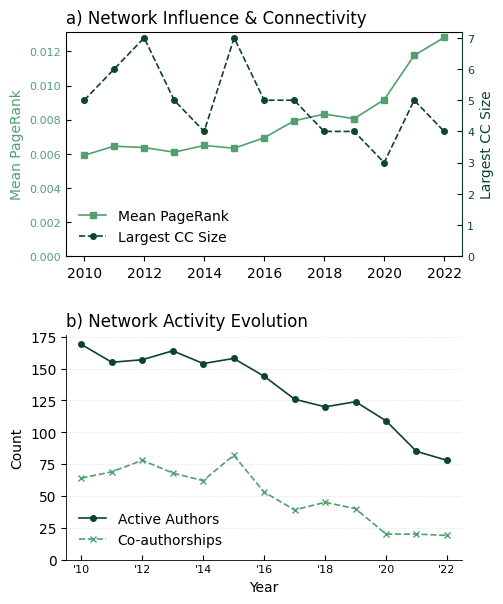

In [125]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(5.5, 6))

# subplot (a): PageRank and Largest CC
ax1_twin = axs[0].twinx()

# plotting on ax1 (PageRank)
line1, = axs[0].plot(years, avg_pagerank_evol, marker="s", linestyle="-", color="#52A06F",
                   label="Mean PageRank", markersize=4, lw=1.2)
axs[0].set_ylabel("Mean PageRank", color="#52A06F", fontsize=10)
axs[0].tick_params(axis="y", labelcolor="#52A06F", labelsize=8, direction="in")
axs[0].set_ylim(bottom=0)

# plotting on ax1_twin (Largest CC)
line2, = ax1_twin.plot(years, largest_comp_evol, marker="o", linestyle="--", color="#0c4529",
                       label="Largest CC Size", markersize=4, lw=1.2)
ax1_twin.set_ylabel("Largest CC Size", color="#0c4529", fontsize=10)
ax1_twin.tick_params(axis="y", labelcolor="#0c4529", labelsize=8, direction="in")
ax1_twin.set_ylim(bottom=0)

lines = [line1, line2]
labels = [l.get_label() for l in lines]
axs[0].legend(lines, labels, loc="lower left", fontsize=10, frameon=False)
axs[0].set_title("a) Network Influence & Connectivity", loc="left", pad=6)

# subplot (b): network activity
axs[1].plot(years, active_nodes_evol, marker="o", linestyle="-", color="#0c4529",
         label="Active Authors", markersize=4, lw=1.2)
axs[1].plot(years, edges_evol, marker="x", linestyle="--", color="#52A06F",
         label="Co-authorships", markersize=4, lw=1.2)

axs[1].set_title("b) Network Activity Evolution", loc="left", pad=6)
axs[1].set_ylabel("Count", fontsize=10)
axs[1].set_ylim(bottom=0)
axs[1].legend(loc="lower left", fontsize=10, frameon=False)


for ax_item in [axs[0], axs[1]]:
    ax_item.set_xlabel("Year", fontsize=10)
    ax_item.xaxis.set_major_locator(MaxNLocator(nbins=7, integer=True, prune="both"))
    ax_item.xaxis.set_major_formatter(FuncFormatter(year_tick_formatter))
    ax_item.tick_params(axis="x", labelsize=8, direction="in")
    ax_item.set_xlim(min(years) - 0.5, max(years) + 0.5)

    ax_item.grid(True, axis="y", linestyle=":", linewidth=0.5, color="lightgray")
    ax_item.spines["top"].set_visible(False)
    ax_item.spines[["bottom", "left"]].set_linewidth(0.6)

axs[0].spines["right"].set_visible(False)
ax1_twin.spines[["top", "left"]].set_visible(False)
ax1_twin.spines[["bottom", "right"]].set_linewidth(0.6)
ax1_twin.spines["right"].set_color("#0c4529")
axs[1].spines["right"].set_visible(False)

fig.subplots_adjust(left=0.14, right=0.86, bottom=0.08, top=0.96, hspace=0.35)

# Density Index ($\mathcal{D}_{(i,j)}$)



$$\mathcal{D}_{(i,j)} = \frac{2 P_i P_j}{P_i + P_j} \cdot \ln(\text{count}_{ij} + 1)$$

In [88]:
df_di = pd.read_csv("edges_anon_2k.csv")
df_di.head()

,Source,Target,Group
0,113,22,1A
1,113,22,1A
2,86,141,1A
3,86,141,1A
4,47,75,1A


In [94]:
index_count = (
    pd.concat([
        df_di.Source,
        df_di.Target
    ])
    .value_counts()
)

index_count.head()

,count
48,272
130,272
7,117
152,106
65,103


In [95]:
canonical_edges = np.sort(df_di[["Source", "Target"]].values, axis=1)
edge_counts = pd.Series([tuple(e) for e in canonical_edges]).value_counts()

df_grouped = pd.DataFrame(edge_counts)
df_grouped.index.name = "Edge"
df_grouped.columns = ["Count"]

total_edges = len(df_di)
df_grouped["Pct_Overall"] = (df_grouped["Count"] / total_edges) * 100

total_author_counts = pd.concat([df_di["Source"], df_di["Target"]]).value_counts()

df_grouped["Total_Author_1"] = df_grouped.index.str[0].map(total_author_counts)
df_grouped["Total_Author_2"] = df_grouped.index.str[1].map(total_author_counts)

df_grouped["Pct_Collab_Author_1"] = (df_grouped["Count"] / df_grouped["Total_Author_1"]) * 100
df_grouped["Pct_Collab_Author_2"] = (df_grouped["Count"] / df_grouped["Total_Author_2"]) * 100

for col in ["Pct_Overall", "Pct_Collab_Author_1", "Pct_Collab_Author_2"]:
    df_grouped[col] = df_grouped[col].map("{:.2f}%".format)

In [96]:
df_grouped.sort_values(by=["Total_Author_1", "Total_Author_2"], ascending=False).head()

,Count,Pct_Overall,Total_Author_1,Total_Author_2,Pct_Collab_Author_1,Pct_Collab_Author_2
Edge,,,,,,
"(48, 130)",272,13.59%,272,272,100.00%,100.00%
"(7, 65)",103,5.14%,117,103,88.03%,100.00%
"(7, 162)",14,0.70%,117,32,11.97%,43.75%
"(82, 127)",90,4.50%,93,90,96.77%,100.00%
"(43, 155)",61,3.05%,84,100,72.62%,61.00%


In [97]:
for col in ["Pct_Collab_Author_1", "Pct_Collab_Author_2"]:
    df_grouped[col] = df_grouped[col].str.replace("%", "").astype(float)

df_grouped["Count"] = df_grouped["Count"].astype(int)

In [98]:
import seaborn as sns

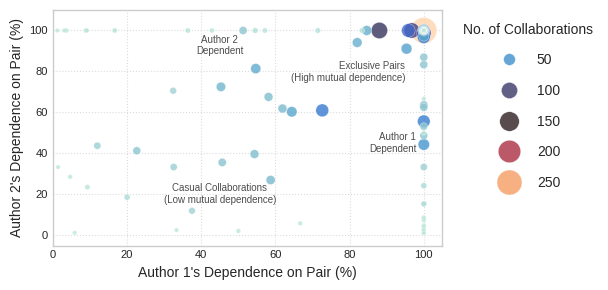

In [99]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(6.2, 3))

scatter = sns.scatterplot(
    data=df_grouped,
    x="Pct_Collab_Author_1",
    y="Pct_Collab_Author_2",
    size="Count",
    sizes=(10, 350),
    alpha=0.8,
    palette="icefire",
    hue="Count",
    legend="auto",
    ax=ax
)

ax.set_xlabel("Author 1's Dependence on Pair (%)", fontsize=10)
ax.set_ylabel("Author 2's Dependence on Pair (%)", fontsize=10)

ax.text(45, 15, "Casual Collaborations\n(Low mutual dependence)", ha="center", va="bottom", fontsize=7, color="k", alpha=0.7)
ax.text(98, 45, "Author 1\nDependent", ha="right", va="center", fontsize=7, color="k", alpha=0.7)
ax.text(45, 98, "Author 2\nDependent", ha="center", va="top", fontsize=7, color="k", alpha=0.7)
ax.text(95, 85, "Exclusive Pairs\n(High mutual dependence)", ha="right", va="top", fontsize=7, color="k", alpha=0.7)

ax.set_xlim(0, 105)
ax.set_ylim(-5, 110)

ax.tick_params(axis="y", labelsize=8, direction="in")
ax.tick_params(axis="x", labelsize=8, direction="in")

# ax.axvline(75, color="grey", linestyle="--", lw=1)
# ax.axhline(75, color="grey", linestyle="--", lw=1)

ax.grid(True, linestyle=":", alpha=0.7)

handles, labels = scatter.get_legend_handles_labels()
ax.legend(
    handles,
    labels,
    title="No. of Collaborations",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    handletextpad=1.0,
    labelspacing=1.2
)

plt.tight_layout()
# plt.savefig("collaboration_scatter_plot.png", dpi=300)